# Faculdade Mackenzie - MBA Inteligência de Dados & Analytics para Negócios

**Disciplina:** Data Science Experience

**Professora:** Professora Poliana Nascimento Ferreira

## Data Science Experience · Trabalho Final

**Tema:** Previsão de atraso na entrega no e-commerce brasileiro (Olist)

**Integrantes:**

- Diego Castilho
- Leandro Oliveira
- Luiz Fernando
- Matheus Ferreira
- Rodrigo Palma
- Sara Barros

### Como executar

O notebook foi desenvolvido no VSCode (macOS) mas também roda no Google Colab. Pode ser executado em
qualquer um dos dois ambientes, rodando todas as células em ordem (`Executar tudo`).

- **Base de dados:** Se a base de dados não estiver em `data/raw/` ao executar a primeira vez ela é baixada direto do Kaggle pelo `kagglehub`.
- **Bibliotecas:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `optuna`, `shap` e
  `kagglehub`. No Colab, a primeira célula instala as que faltarem.
- **Ambiente local:** Python 3.13 em um ambiente virtual (`.venv`) criado com o `uv`. As dependências estão
  no `pyproject.toml` e no `uv.lock`, e o ambiente pode ser recriado com `uv sync`. Versões usadas:
  pandas 3.0, scikit-learn 1.8, optuna 5.0 e shap 0.52.
- **Tempo estimado para execução:** cerca de 20 minutos no Mac usado no desenvolvimento e de 30 a 45 minutos no Colab gratuito. A etapa de AutoML
  (item 7) foi a que mais demorou para rodar.

### Uso de inteligência artificial

- O trabalho foi construído em reuniões online de discussão do grupo. O grupo usou ferramentas de IA como apoio na criação do trabalho.
- As decisões de problema, target, métricas e interpretação dos resultados foram discutidas e validadas pelo grupo.


### Preparação do ambiente

A primeira célula prepara o ambiente de execução:

- **Instalação:** verifica se `shap`, `optuna` e `kagglehub` estão instalados e instala os que faltarem.
  No Colab essas bibliotecas não vêm por padrão; no ambiente local a verificação não instala nada.
- **Importações:** carrega as bibliotecas de manipulação de dados (`pandas`, `numpy`) e de gráficos
  (`matplotlib`, `seaborn`). As bibliotecas de Machine Learning são importadas no item 5.
- **Configurações:** oculta avisos que não afetam os resultados, mostra todas as colunas das tabelas e
  define um estilo padrão para os gráficos.
- **`RANDOM_STATE = 42`:** fixa a semente dos sorteios do notebook (divisão entre treino e teste, folds da
  validação cruzada, modelos e Optuna). Assim, cada execução gera os mesmos resultados e todos os modelos
  são comparados nas mesmas condições. O número 42 foi uma escolha aleatória.


In [ ]:
import importlib.util, subprocess, sys

for pacote in ["shap", "optuna", "kagglehub"]:
    if importlib.util.find_spec(pacote) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 1. Escolha da base de dados

Base escolhida: **Brazilian E-Commerce Public Dataset by Olist**. Disponível no
[Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). São dados reais, anonimizados, de
cerca de 100 mil pedidos feitos entre 2016 e 2018 no marketplace da Olist, que conecta pequenos lojistas
aos grandes portais de e-commerce, como Mercado Livre e Amazon.

A base atende aos critérios da atividade:

- Não é uma base clássica de exemplo, como Iris ou Titanic.
- Permite aprendizado supervisionado, pois as datas de entrega e de prazo prometido geram um target real
  para classificação e para regressão.
- Tem complexidade suficiente: são 9 tabelas relacionais que precisam ser combinadas antes da análise.
- Tem problemas reais de qualidade, como datas inconsistentes, coordenadas fora do Brasil, avaliações
  duplicadas, valores ausentes e outliers, tratados no item 3.


## 2. Definição do problema

**Contexto.** Quando o cliente compra na Olist, recebe uma data prometida de entrega. O vendedor posta o
produto e uma transportadora faz a entrega. Depois, o cliente avalia o pedido com uma nota de 1 a 5, que
afeta a reputação do vendedor e da plataforma.

**Problema.** Parte dos pedidos chega depois da data prometida, e a análise exploratória (item 4) mostra
que o atraso é o principal motivo das notas ruins. Hoje a plataforma só descobre o atraso quando ele já
aconteceu.

**Objetivo.** Prever o atraso no momento em que o vendedor posta o pedido. Nesse ponto ainda é possível
agir, por exemplo priorizando a entrega ou avisando o cliente.

|                            |                                                                                                                                                                                                                  |
| -------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Target (classificação)** | `target_atraso`: 1 se o pedido chegou depois da data prometida, 0 caso contrário                                                                                                                                 |
| **Target (regressão)**     | `atraso_dias`: dias entre a entrega real e a data prometida (negativo = chegou antes)                                                                                                                            |
| **Tipo de problema**       | Classificação binária (vai atrasar?) e regressão (quantos dias?), a partir da mesma variável                                                                                                                     |
| **Informações usadas**     | Dados do pedido (itens, valores, frete, pagamento), do produto (peso, volume, categoria), da geografia (UF, região e distância entre cliente e vendedor), prazo prometido, data da compra e tempo até o despacho |

O item 5.3 compara esse target com outras opções e mostra por que ele foi escolhido.


## 3. Compreensão e limpeza dos dados

### 3.1. Construção da base analítica

Como a base vem em 9 tabelas, o grupo definiu que cada linha da base final seria **um pedido**. As tabelas
com vários registros por pedido (itens, pagamentos e avaliações) foram agregadas antes de cada junção, para
não duplicar pedidos.


In [ ]:
# Usa a cópia local se existir; senão (ex.: Colab) baixa do Kaggle
if os.path.exists("data/raw/olist_orders_dataset.csv"):
    RAW = "data/raw"
else:
    import kagglehub

    RAW = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

datas = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
orders = pd.read_csv(f"{RAW}/olist_orders_dataset.csv", parse_dates=datas)
print(f"Pedidos na base original: {len(orders):,}")
print(orders["order_status"].value_counts().to_string())

Pedidos na base original: 99,441
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


In [ ]:
# Só pedidos entregues têm o ciclo completo de datas
df = orders[orders["order_status"] == "delivered"].copy()

# Clientes
df = df.merge(pd.read_csv(f"{RAW}/olist_customers_dataset.csv"), on="customer_id", how="left")

# Itens: agregados por pedido
items = pd.read_csv(f"{RAW}/olist_order_items_dataset.csv")
itens_agg = items.groupby("order_id").agg(
    qtd_itens=("order_item_id", "count"),
    qtd_produtos_distintos=("product_id", "nunique"),
    qtd_vendedores=("seller_id", "nunique"),
    valor_produtos=("price", "sum"),
    valor_frete=("freight_value", "sum"),
    preco_medio_item=("price", "mean"),
)
df = df.merge(itens_agg, on="order_id", how="left")

# Produto e vendedor "principais" = os do item mais caro (87% dos pedidos têm 1 item só)
principal = (
    items.sort_values("price", ascending=False)
    .groupby("order_id")
    .first()[["product_id", "seller_id"]]
)
df = df.merge(principal, on="order_id", how="left")

# Produtos e vendedores
products = pd.read_csv(f"{RAW}/olist_products_dataset.csv")
products["volume_cm3"] = (
    products["product_length_cm"] * products["product_height_cm"] * products["product_width_cm"]
)
df = df.merge(
    products[
        [
            "product_id",
            "product_category_name",
            "product_weight_g",
            "volume_cm3",
            "product_photos_qty",
            "product_description_lenght",
        ]
    ],
    on="product_id",
    how="left",
)
df = df.merge(pd.read_csv(f"{RAW}/olist_sellers_dataset.csv"), on="seller_id", how="left")

# Pagamentos: agregados por pedido + forma de pagamento principal
payments = pd.read_csv(f"{RAW}/olist_order_payments_dataset.csv")
pag_agg = payments.groupby("order_id").agg(
    valor_pago=("payment_value", "sum"),
    qtd_parcelas=("payment_installments", "max"),
    qtd_formas_pagamento=("payment_sequential", "count"),
)
forma = (
    payments.sort_values("payment_value", ascending=False)
    .groupby("order_id")
    .first()[["payment_type"]]
    .rename(columns={"payment_type": "tipo_pagamento"})
)
df = df.merge(pag_agg, on="order_id", how="left").merge(forma, on="order_id", how="left")

# Avaliações: alguns pedidos têm mais de uma; mantém a mais recente
reviews = pd.read_csv(
    f"{RAW}/olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
print(f"Pedidos com mais de uma avaliação: {(reviews['order_id'].value_counts() > 1).sum()}")
reviews = reviews.sort_values("review_answer_timestamp").groupby("order_id").last().reset_index()
reviews["tem_comentario"] = np.where(reviews["review_comment_message"].notna(), "Sim", "Nao")
df = df.merge(reviews[["order_id", "review_score", "tem_comentario"]], on="order_id", how="left")

print(f"Base analítica: {df.shape[0]:,} pedidos x {df.shape[1]} colunas")

Pedidos com mais de uma avaliação: 547
Base analítica: 96,478 pedidos x 34 colunas


In [ ]:
# Geolocalização: 1 milhão de linhas para ~19 mil CEPs
geo = pd.read_csv(f"{RAW}/olist_geolocation_dataset.csv")
dentro_br = geo["geolocation_lat"].between(-33.75, 5.28) & geo["geolocation_lng"].between(
    -73.99, -34.79
)
print(f"Coordenadas fora do Brasil removidas: {(~dentro_br).sum()}")
geo = (
    geo[dentro_br]
    .groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .mean()
)

df = df.merge(
    geo.rename(columns={"geolocation_lat": "lat_cli", "geolocation_lng": "lng_cli"}),
    left_on="customer_zip_code_prefix",
    right_index=True,
    how="left",
)
df = df.merge(
    geo.rename(columns={"geolocation_lat": "lat_vnd", "geolocation_lng": "lng_vnd"}),
    left_on="seller_zip_code_prefix",
    right_index=True,
    how="left",
)


def haversine(lat1, lon1, lat2, lon2):
    """Distância em km entre dois pontos, considerando a curvatura da Terra."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (
        np.sin((lat2 - lat1) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    )
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))


df["distancia_km"] = haversine(df["lat_cli"], df["lng_cli"], df["lat_vnd"], df["lng_vnd"])

Coordenadas fora do Brasil removidas: 42


In [ ]:
# Variáveis derivadas: as datas brutas viram durações
dia = np.timedelta64(1, "D")
df["tempo_entrega_dias"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
) / dia
df["prazo_estimado_dias"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
) / dia
df["atraso_dias"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
) / dia
df["tempo_aprovacao_horas"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
) / np.timedelta64(1, "h")
df["tempo_postagem_dias"] = (df["order_delivered_carrier_date"] - df["order_approved_at"]) / dia
df["tempo_transporte_dias"] = (
    df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]
) / dia

df["valor_total"] = df["valor_produtos"] + df["valor_frete"]
df["pct_frete"] = 100 * df["valor_frete"] / df["valor_total"]
df["mes_compra"] = df["order_purchase_timestamp"].dt.month
df["hora_compra"] = df["order_purchase_timestamp"].dt.hour
df["dia_semana_compra"] = df["order_purchase_timestamp"].dt.day_name()
df["ano_mes_compra"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["mesma_uf"] = np.where(df["customer_state"] == df["seller_state"], "Sim", "Nao")

### 3.2. Problemas de qualidade encontrados


In [ ]:
# Durações negativas: entrega registrada antes da postagem (impossível)
for c in ["tempo_postagem_dias", "tempo_transporte_dias", "tempo_entrega_dias"]:
    print(f"{c}: {(df[c] < 0).sum()} valores negativos -> viram ausentes")
    df.loc[df[c] < 0, c] = np.nan

# Pedidos "entregues" sem data de entrega: não dá para saber se atrasaram
sem_entrega = df["atraso_dias"].isna().sum()
df = df[df["atraso_dias"].notna()].copy()
print(f"\nPedidos sem data de entrega removidos: {sem_entrega}")

# Target
df["target_atraso"] = (df["atraso_dias"] > 0).astype(int)

print(f"Pedidos duplicados: {df['order_id'].duplicated().sum()}")
print(f"Produtos com peso 0 g: {(df['product_weight_g'] == 0).sum()}")
print(
    f"Base final: {len(df):,} pedidos | período {df['order_purchase_timestamp'].min():%m/%Y} a "
    f"{df['order_purchase_timestamp'].max():%m/%Y}"
)

ausentes = (df.isna().mean() * 100).round(2)
ausentes[ausentes > 0].sort_values(ascending=False).to_frame("% ausente").head(12)

tempo_postagem_dias: 1350 valores negativos -> viram ausentes
tempo_transporte_dias: 23 valores negativos -> viram ausentes
tempo_entrega_dias: 0 valores negativos -> viram ausentes

Pedidos sem data de entrega removidos: 8
Pedidos duplicados: 0
Produtos com peso 0 g: 6
Base final: 96,470 pedidos | período 09/2016 a 08/2018


,% ausente
product_category_name,1.41
product_photos_qty,1.41
product_description_lenght,1.41
tempo_postagem_dias,1.41
review_score,0.67
tem_comentario,0.67
distancia_km,0.49
lat_cli,0.27
lng_cli,0.27
lat_vnd,0.22


Resumo dos problemas encontrados e dos tratamentos aplicados:

| Problema                                                                  | Tratamento                                         | Justificativa                                                                                                                                                                                          |
| ------------------------------------------------------------------------- | -------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Base em 9 tabelas, algumas com várias linhas por pedido                   | Agregação por pedido antes de cada junção          | Evita pedidos duplicados e taxas distorcidas                                                                                                                                                           |
| 547 pedidos com mais de uma avaliação                                     | Mantida a mais recente                             | Representa a opinião final do cliente                                                                                                                                                                  |
| Pedidos não entregues (cancelados, em trânsito, cerca de 3%)              | Removidos                                          | Sem data de entrega não há como medir atraso                                                                                                                                                           |
| 8 pedidos "entregues" sem data de entrega                                 | Removidos                                          | O target fica indefinido                                                                                                                                                                               |
| 42 coordenadas fora do Brasil                                             | Removidas                                          | São erros de cadastro e distorceriam as distâncias                                                                                                                                                     |
| Durações negativas (1.350 na postagem e 23 no transporte)                 | Transformadas em ausentes                          | São impossíveis; o restante do pedido continua válido                                                                                                                                                  |
| Valores ausentes (até 1,4%: categoria, fotos, distância)                  | Imputados dentro do pipeline (item 5)              | São poucos, e a imputação feita só com o treino evita vazamento                                                                                                                                        |
| Produtos com peso 0 g                                                     | Mantidos; ajuste apenas no cálculo de frete por kg | Evita divisão por zero sem perder o pedido                                                                                                                                                             |
| Outliers (entrega de 209 dias, atraso de +189 dias, pedidos de R$ 13 mil) | Mantidos                                           | São casos reais, não erros. Removê-los eliminaria justamente os atrasos graves que se quer prever. Por isso foram usados modelos de árvore, menos sensíveis a outliers, e o MAE como métrica principal |


## 4. Análise exploratória baseada em perguntas

A análise foi organizada em perguntas. Cada pergunta tem um gráfico ou tabela e nossa interpretação. A
métrica mais usada foi a taxa de atraso, o percentual de pedidos atrasados em cada grupo.


In [7]:
def taxa_atraso(grupos, titulo, xlabel, ordenar=False, ax=None):
    """Gráfico de barras com a taxa de atraso (%) de cada grupo."""
    taxa = df.groupby(grupos, observed=True)["target_atraso"].mean() * 100
    if ordenar:
        taxa = taxa.sort_values(ascending=False)
    ax = ax or plt.subplots(figsize=(9, 4.5))[1]
    taxa.plot(kind="bar", color="darkorange", ax=ax)
    ax.axhline(df["target_atraso"].mean() * 100, color="gray", linestyle="--", label="Média geral")
    for i, v in enumerate(taxa):
        ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pedidos atrasados (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.legend()
    return taxa

### Pergunta 1: quantos pedidos atrasam, e quanto?


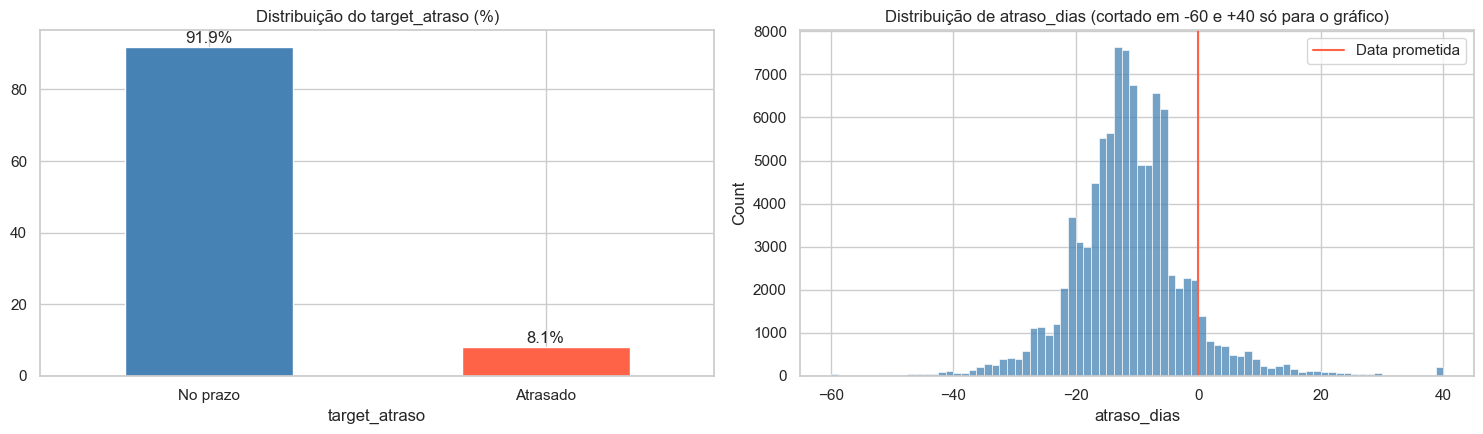

count    96470.0
mean       -11.2
std         10.2
min       -146.0
25%        -16.2
50%        -11.9
75%         -6.4
max        189.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
df["target_atraso"].map({0: "No prazo", 1: "Atrasado"}).value_counts(normalize=True).mul(100).plot(
    kind="bar", color=["steelblue", "tomato"], ax=axes[0]
)
axes[0].set_title("Distribuição do target_atraso (%)")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(df["target_atraso"].value_counts(normalize=True).mul(100)):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")

sns.histplot(df["atraso_dias"].clip(-60, 40), bins=80, color="steelblue", ax=axes[1])
axes[1].axvline(0, color="tomato", label="Data prometida")
axes[1].set_title("Distribuição de atraso_dias (cortado em -60 e +40 só para o gráfico)")
axes[1].legend()
plt.tight_layout()
plt.show()

print(df["atraso_dias"].describe().round(1).to_string())

**Interpretação:** 8,1% dos pedidos atrasaram. As classes são desbalanceadas, mas o atraso não chega a
ser um evento raro, e isso foi tratado na modelagem com pesos de classe. O prazo prometido é conservador:
na mediana, o pedido chega 12 dias antes do prometido. Mesmo assim, existem atrasos graves, como por
exemplo 189 dias. Como `atraso_dias` é contínua, ela também serve como target de regressão.


### Pergunta 2: o atraso afeta a satisfação do cliente?

Dúvida inicial do projeto: só faz sentido prever o atraso se ele de fato prejudica a experiência do cliente e puxa a nota para baixo.


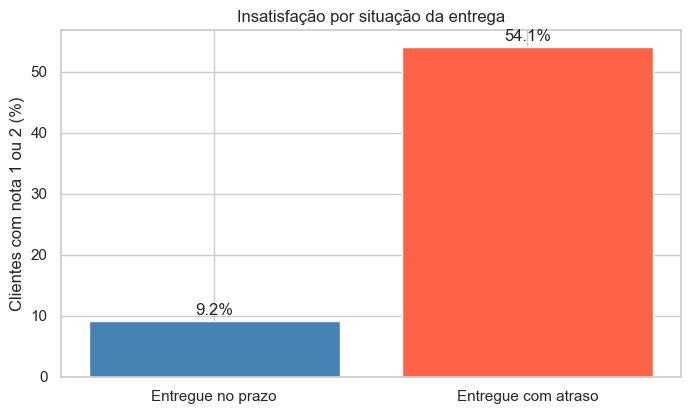

Nota média: no prazo = 4.29 | atrasado = 2.57
Razão de insatisfação: 5.9x


In [ ]:
avaliados = df[df["review_score"].notna()]
insatisfeito = (avaliados["review_score"] <= 2).groupby(avaliados["target_atraso"]).mean() * 100
nota_media = avaliados.groupby("target_atraso")["review_score"].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    ["Entregue no prazo", "Entregue com atraso"], insatisfeito.values, color=["steelblue", "tomato"]
)
for i, v in enumerate(insatisfeito.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)
ax.set_ylabel("Clientes com nota 1 ou 2 (%)")
ax.set_title("Insatisfação por situação da entrega")
plt.show()
print(f"Nota média: no prazo = {nota_media[0]:.2f} | atrasado = {nota_media[1]:.2f}")
print(f"Razão de insatisfação: {insatisfeito[1] / insatisfeito[0]:.1f}x")

**Interpretação:** sim, e de forma consistente. Entre os pedidos entregues no prazo, 9,2% dos clientes dão nota
1 ou 2. Entre os atrasados, 54,1% dão nota, aproximadamente 6 vezes mais, e a nota média cai de 4,29 para 2,57. Por isso decidimos
prever o atraso, pois ele é a principal causa da insatisfação e pode ser previsto antes da avaliação do cliente.


### Pergunta 3: o tempo que o vendedor leva para postar influencia o atraso?


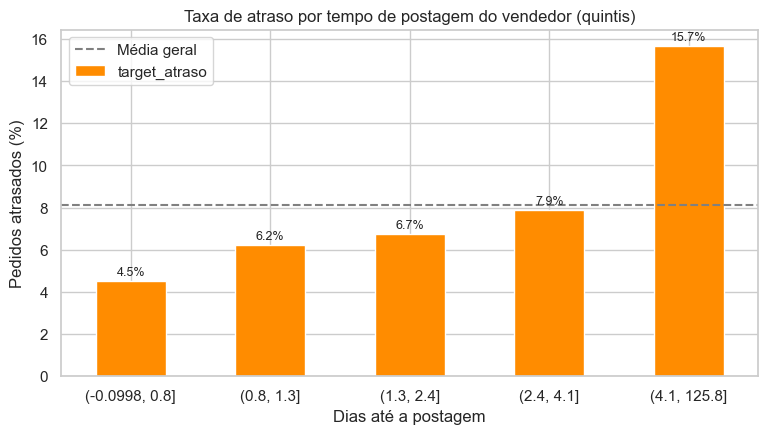

In [ ]:
taxa_atraso(
    pd.qcut(df["tempo_postagem_dias"], 5, precision=1),
    "Taxa de atraso por tempo de postagem do vendedor (quintis)",
    "Dias até a postagem",
)
plt.show()

**Interpretação:** sim. A taxa de atraso sobe de 4,5%, quando o vendedor posta em menos de 1 dia, para
15,7%, quando ele leva mais de 4 dias. O dado é útil porque o prazo de postagem pode ser cobrado dos vendedores.
Isso justifica fazer a previsão no despacho também.


### Pergunta 4: a localização do cliente e a distância até o vendedor importam?


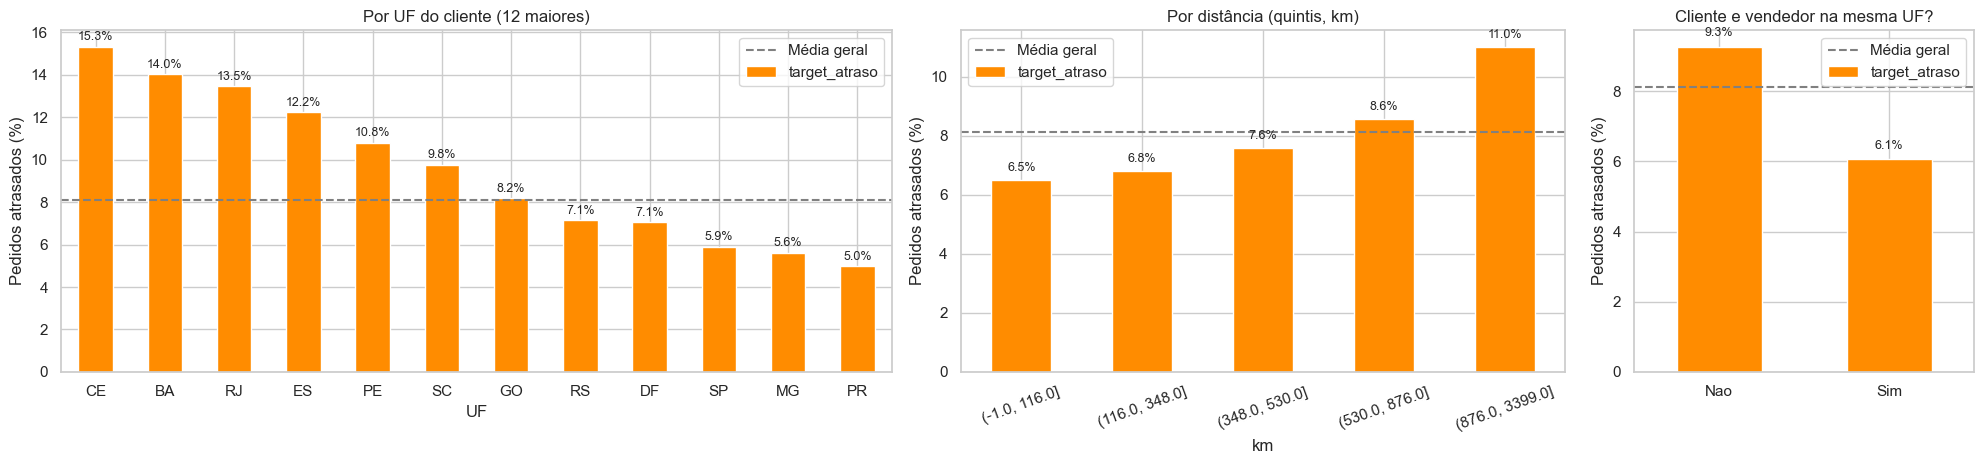

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.8), gridspec_kw={"width_ratios": [2.2, 1.6, 0.9]})
top_uf = df["customer_state"].value_counts().head(12).index
taxa_atraso(
    df["customer_state"].where(df["customer_state"].isin(top_uf)),
    "Por UF do cliente (12 maiores)",
    "UF",
    ordenar=True,
    ax=axes[0],
)
taxa_atraso(
    pd.qcut(df["distancia_km"], 5, precision=0), "Por distância (quintis, km)", "km", ax=axes[1]
)
axes[1].tick_params(axis="x", rotation=20)
taxa_atraso(df["mesma_uf"], "Cliente e vendedor na mesma UF?", "", ax=axes[2])
plt.tight_layout()
plt.show()

**Interpretação:** sim, a geografia importa.

- **UF:** Ceará (15,3%), Bahia (14,0%) e Rio de Janeiro (13,5%) têm as maiores taxas de atraso; Paraná (5,0%), Minas
  Gerais (5,6%) e São Paulo (5,9%), as menores.
- **Distância:** a taxa sobe de 6,5% nos pedidos mais próximos para 11,0% nos mais distantes.
- **Mesma UF:** pedidos dentro do mesmo estado atrasam menos (6,1% contra 9,3%).

O Rio de Janeiro chama atenção por ficar perto de São Paulo, onde está a maioria dos vendedores, mas
atrasa como o Nordeste, o que sugere um problema na entrega local, não de distância.


### Pergunta 5: existem épocas do ano com mais atraso?


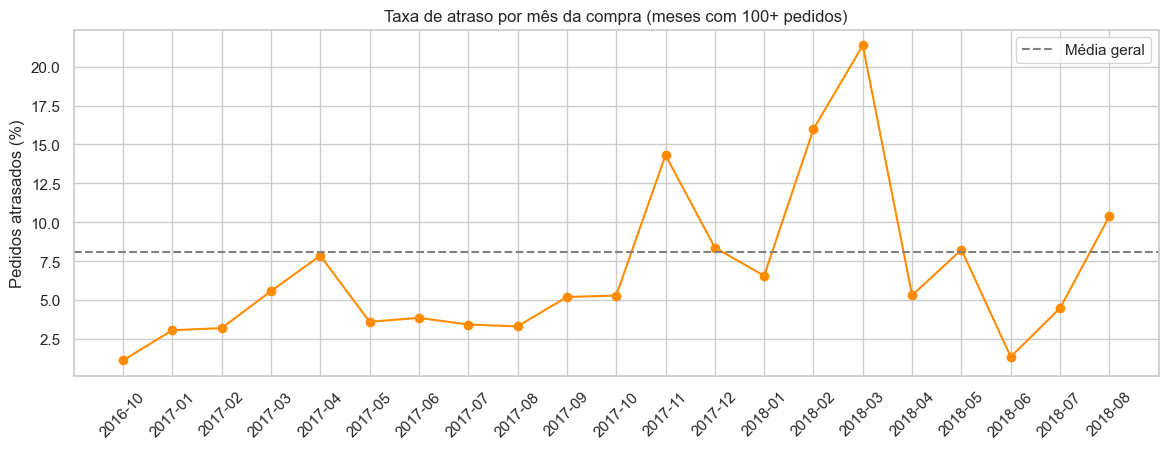

In [ ]:
volume = df["ano_mes_compra"].value_counts()
serie = (
    df[df["ano_mes_compra"].isin(volume[volume >= 100].index)]
    .groupby("ano_mes_compra")["target_atraso"]
    .mean()
    * 100
).sort_index()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(serie.index, serie.values, marker="o", color="darkorange")
ax.axhline(df["target_atraso"].mean() * 100, color="gray", linestyle="--", label="Média geral")
ax.set_title("Taxa de atraso por mês da compra (meses com 100+ pedidos)")
ax.set_ylabel("Pedidos atrasados (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.show()

**Interpretação:** sim. Na maior parte a taxa fica entre 5% e 8%, mas vemos picos em novembro de
2017 (14,3%), mês da Black Friday e em fevereiro e março de 2018 (16,0% e 21,4%) o pior momento da
série. A logística satura nos períodos de pico, o que pode indicar que o mês da compra ajuda o modelo.


### Pergunta 6: valor do pedido, frete e peso do produto explicam o atraso?


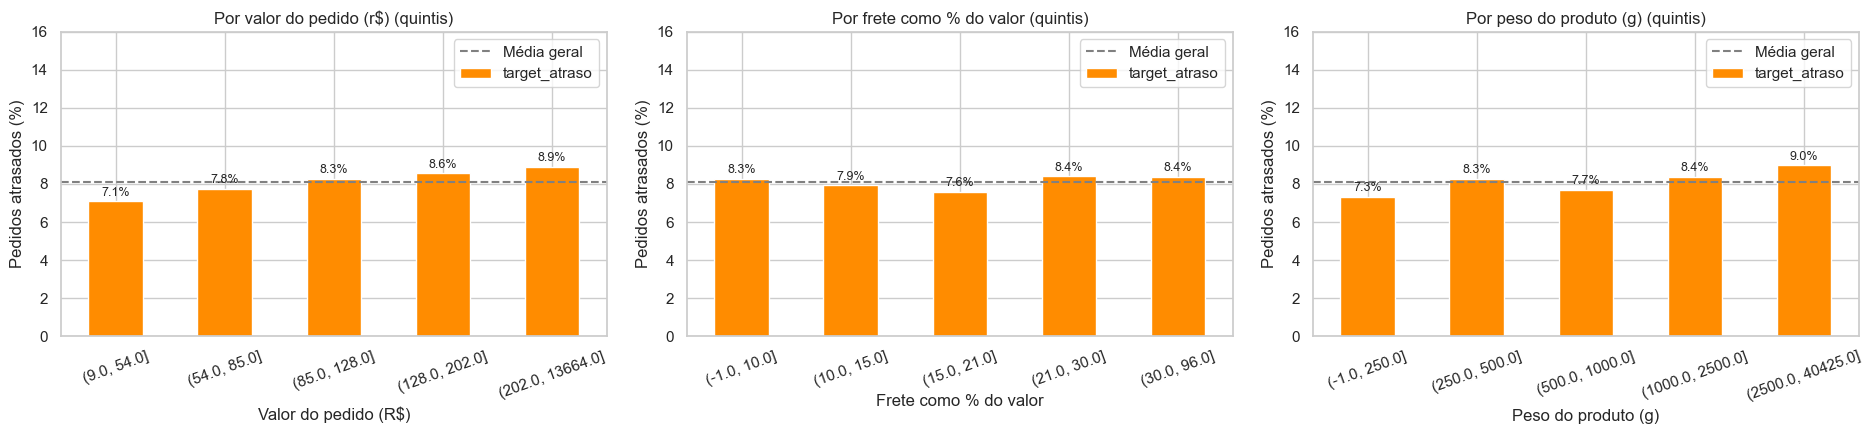

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
for ax, (col, nome) in zip(
    axes,
    [
        ("valor_total", "Valor do pedido (R$)"),
        ("pct_frete", "Frete como % do valor"),
        ("product_weight_g", "Peso do produto (g)"),
    ],
):
    taxa_atraso(pd.qcut(df[col], 5, precision=0), f"Por {nome.lower()} (quintis)", nome, ax=ax)
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylim(0, 16)
plt.tight_layout()
plt.show()

**Interpretação:** praticamente não. A taxa de atraso fica entre 7% e 9% em todas as faixas de valor, de
frete e de peso. A expectativa era de que produtos pesados atrasassem mais, mas a diferença foi pequena. O
atraso depende mais do processo (postagem, rota e época) do que do produto.


### Pergunta 7: como um pedido atrasado se compara a um pedido no prazo?


In [ ]:
cols = [
    "tempo_postagem_dias",
    "prazo_estimado_dias",
    "distancia_km",
    "valor_total",
    "valor_frete",
    "product_weight_g",
]
perfil = df.groupby("target_atraso")[cols].median().T
perfil.columns = ["No prazo (mediana)", "Atrasado (mediana)"]
perfil["Diferença %"] = (perfil["Atrasado (mediana)"] / perfil["No prazo (mediana)"] - 1) * 100
perfil.round(1)

,No prazo (mediana),Atrasado (mediana),Diferença %
tempo_postagem_dias,1.8,3.0,69.1
prazo_estimado_dias,23.3,22.2,-4.6
distancia_km,426.4,511.8,20.0
valor_total,104.6,112.2,7.3
valor_frete,17.1,18.1,5.8
product_weight_g,700.0,750.0,7.1


**Interpretação:** no pedido atrasado, o vendedor leva 70% mais tempo para postar (3,0 contra 1,8 dia), a
distância é 20% maior e o prazo prometido é um pouco menor. Parte do problema está em prometer
prazos curtos justamente onde a entrega é mais difícil. Valor, frete e peso quase não mudam entre os dois
grupos. O atraso está ligado a prazo, postagem e rota.


## 5. Preparação dos dados para Machine Learning

### 5.1. Variáveis permitidas e data leakage

Como a previsão é feita no despacho, o modelo só pode usar informações disponíveis nesse momento. Foram
excluídas:

| Variáveis excluídas                                             | Motivo                                                                           |
| --------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| `tempo_entrega_dias`, `tempo_transporte_dias`, data de entrega  | Só existem depois da entrega e revelam a resposta                                |
| `review_score`, `tem_comentario`                                | A avaliação acontece depois da entrega                                           |
| IDs (`order_id`, `customer_id`, `product_id`, `seller_id` etc.) | Não têm significado para as perguntas.                                           |
| Cidades e CEPs                                                  | Milhares de valores diferentes. Usar UF, região e distância simplificou o modelo |
| `valor_total`, `valor_pago`                                     | Repetem a soma dos campos `valor_produtos` e `valor_frete`                       |

Imputação, padronização e codificação ficam dentro de um `Pipeline`, ajustado apenas com os dados de treino.

### 5.2. Engenharia de características

Foram criadas quatro variáveis. Todas são calculadas pedido a pedido, sem usar estatísticas da base, para não gerarem vazamento.

- **`folga_prazo_dias`:** dias que sobram para a transportadora no despacho (prazo prometido menos tempo de aprovação e tempo de postagem). Resume o que foi visto nas Perguntas 3 e 7.
- **`frete_por_kg`:** frete dividido pelo peso, indicador de rota mais cara.
- **`regiao_cliente` e `regiao_vendedor`:** agrupam as 27 UFs em 5 regiões. Muitas localidades têm poucos pedidos.
- **`compra_fim_semana`:** compras de sábado e domingo só são processadas na segunda.


In [ ]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_validate,
    cross_val_score,
    cross_val_predict,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
import optuna
import shap

In [ ]:
REGIOES = {
    "AC": "Norte",
    "AM": "Norte",
    "AP": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",
    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",
    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MS": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",
    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul",
}

df_ml = df.copy()
df_ml["folga_prazo_dias"] = (
    df_ml["prazo_estimado_dias"]
    - df_ml["tempo_aprovacao_horas"] / 24
    - df_ml["tempo_postagem_dias"]
)
df_ml["frete_por_kg"] = df_ml["valor_frete"] / (df_ml["product_weight_g"].clip(lower=50) / 1000)
df_ml["regiao_cliente"] = df_ml["customer_state"].map(REGIOES)
df_ml["regiao_vendedor"] = df_ml["seller_state"].map(REGIOES)
df_ml["compra_fim_semana"] = df_ml["dia_semana_compra"].isin(["Saturday", "Sunday"]).astype(int)

# A variável nova separa bem o target?
print("Taxa de atraso por quintil de folga no despacho:")
print(
    (
        df_ml.groupby(pd.qcut(df_ml["folga_prazo_dias"], 5, precision=1), observed=True)[
            "target_atraso"
        ].mean()
        * 100
    )
    .round(1)
    .to_string()
)

Taxa de atraso por quintil de folga no despacho:
folga_prazo_dias
(-99.8, 13.4]    13.2
(13.4, 18.5]      9.0
(18.5, 21.6]      7.5
(21.6, 27.1]      6.9
(27.1, 148.1]     4.4


A folga se comportou como o esperado: a taxa de atraso cai de 13,2% nos pedidos com menos folga para 4,4%
nos pedidos com mais folga.

### 5.3. Escolha do target

Antes de definir o target, testamos cinco opções com o mesmo modelo.
Cada opção usa apenas as informações disponíveis no seu momento de previsão.
A comparação é feita contra uma referência simples, um classificador aleatório, ou chutar sempre a mediana no caso da regressão.


In [ ]:
num_features = [
    "qtd_itens",
    "qtd_vendedores",
    "valor_produtos",
    "valor_frete",
    "pct_frete",
    "qtd_parcelas",
    "product_weight_g",
    "volume_cm3",
    "product_photos_qty",
    "distancia_km",
    "lat_cli",
    "lng_cli",
    "lat_vnd",
    "lng_vnd",
    "prazo_estimado_dias",
    "tempo_aprovacao_horas",
    "tempo_postagem_dias",
    "folga_prazo_dias",
    "frete_por_kg",
    "mes_compra",
    "hora_compra",
    "compra_fim_semana",
]
cat_features = [
    "customer_state",
    "seller_state",
    "regiao_cliente",
    "regiao_vendedor",
    "mesma_uf",
    "tipo_pagamento",
    "product_category_name",
]


def criar_pipeline(modelo, num_cols=None):
    """Pré-processamento + modelo. Numéricas: mediana + padronização.
    Categóricas: 'desconhecido' + one-hot (níveis com menos de 1% viram 'infrequent')."""
    prep = ColumnTransformer(
        [
            (
                "num",
                Pipeline(
                    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
                ),
                num_cols or num_features,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="infrequent_if_exist",
                                min_frequency=0.01,
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                cat_features,
            ),
        ],
        verbose_feature_names_out=False,
    )
    return Pipeline([("prep", prep), ("modelo", modelo)])


def testar_target(nome, tipo, momento, y, extras=()):
    cols = num_features + list(extras)
    ok = y.notna()
    Xa, Xb, ya, yb = train_test_split(
        df_ml.loc[ok, cols + cat_features],
        y[ok],
        test_size=0.2,
        stratify=y[ok] if tipo == "Classificação" else None,
        random_state=RANDOM_STATE,
    )
    if tipo == "Classificação":
        p = (
            criar_pipeline(
                HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                cols,
            )
            .fit(Xa, ya)
            .predict_proba(Xb)[:, 1]
        )
        valor, ref = average_precision_score(yb, p), yb.mean()
        return [nome, tipo, momento, "PR-AUC", valor, ref, f"{valor / ref:.1f}x melhor"]
    p = (
        criar_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE), cols)
        .fit(Xa, ya)
        .predict(Xb)
    )
    valor, ref = mean_absolute_error(yb, p), mean_absolute_error(yb, np.full(len(yb), ya.median()))
    ganho = (
        f"{1 - valor / ref:.0%} menos erro"
        if valor < ref
        else f"{valor / ref - 1:.0%} mais erro (pior)"
    )
    return [nome, tipo, momento, "MAE", valor, ref, ganho]


pos_entrega = ["tempo_entrega_dias", "tempo_transporte_dias", "atraso_dias"]
insatisfeito = (df_ml["review_score"] <= 2).astype(float).where(df_ml["review_score"].notna())

pd.DataFrame(
    [
        testar_target(
            "Insatisfação (nota 1-2)", "Classificação", "Pós-entrega", insatisfeito, pos_entrega
        ),
        testar_target(
            "Nota da avaliação (1-5)",
            "Regressão",
            "Pós-entrega",
            df_ml["review_score"],
            pos_entrega,
        ),
        testar_target("Pedido atrasado", "Classificação", "Despacho", df_ml["target_atraso"]),
        testar_target(
            "Tempo total de entrega", "Regressão", "Despacho", df_ml["tempo_entrega_dias"]
        ),
        testar_target("Dias de atraso", "Regressão", "Despacho", df_ml["atraso_dias"]),
    ],
    columns=["Target", "Tipo", "Momento", "Métrica", "Modelo", "Referência", "Ganho"],
).round(3)

,Target,Tipo,Momento,Métrica,Modelo,Referência,Ganho
0,Insatisfação (nota 1-2),Classificação,Pós-entrega,PR-AUC,0.481,0.128,3.8x melhor
1,Nota da avaliação (1-5),Regressão,Pós-entrega,MAE,0.866,0.857,1% mais erro (pior)
2,Pedido atrasado,Classificação,Despacho,PR-AUC,0.477,0.081,5.9x melhor
3,Tempo total de entrega,Regressão,Despacho,MAE,4.001,6.098,34% menos erro
4,Dias de atraso,Regressão,Despacho,MAE,3.998,6.777,41% menos erro


**Target escolhido:** o atraso, como classificação (`target_atraso`) e como regressão (`atraso_dias`).

**Motivadores:**

- **Teve o maior ganho sobre a referência.** Na classificação, ficou 5,9 vezes acima do aleatório, contra
  3,8 vezes da insatisfação. Na regressão, reduziu o erro em 41%.
- **A nota da avaliação não funciona como regressão.** O modelo erra mais do que chutar a mediana, porque
  a nota quase sempre é 5 ou 1.
- **Permite agir a tempo.** O atraso é previsto no despacho, enquanto a insatisfação só pode ser prevista
  depois da entrega.
- **É a principal causa da insatisfação**, como mostrou a Pergunta 2.

### 5.4. Separação entre X e Y e entre treino e teste

Usamos uma divisão de 80/20 para os dois problemas, mantendo a mesma proporção de atrasos
(`target_atraso`) no treino e no teste. O conjunto de teste só é usado na avaliação final
(item 8).


In [ ]:
X = df_ml[num_features + cat_features]
y_clf = df_ml["target_atraso"]
y_reg = df_ml["atraso_dias"]

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_clf, y_reg, test_size=0.20, stratify=y_clf, random_state=RANDOM_STATE
)

print(
    f"Treino: {len(X_train):,} | Teste: {len(X_test):,} | Variáveis: {X.shape[1]} "
    f"({len(num_features)} numéricas + {len(cat_features)} categóricas)"
)
print(f"Taxa de atraso — treino: {yc_train.mean():.2%} | teste: {yc_test.mean():.2%}")
print(
    f"Colunas após o pré-processamento: {criar_pipeline(None).named_steps['prep'].fit_transform(X_train).shape[1]}"
)

Treino: 77,176 | Teste: 19,294 | Variáveis: 29 (22 numéricas + 7 categóricas)
Taxa de atraso — treino: 8.11% | teste: 8.11%


Colunas após o pré-processamento: 81


A padronização (`StandardScaler`) é necessária para Regressão Logística, Regressão Linear, KNN e Rede
Neural, que são sensíveis à escala. Para os modelos de árvore ela não faz diferença, mas o mesmo pipeline
foi mantido em todos os modelos para que a comparação fosse justa.


## 6. Modelagem

Foram testados os seis modelos sugeridos na atividade para cada problema, além de um baseline que sempre
dá a resposta mais comum. A comparação usa validação cruzada de 5 folds no conjunto de treino.

Principais escolhas:

- `class_weight="balanced"` nos modelos que aceitam esse parâmetro, para compensar o desbalanceamento.
- No Gradient Boosting foi usado o `HistGradientBoosting` do scikit-learn, mais rápido que a versão
  tradicional em uma base de 77 mil linhas.

**Métricas.** Na classificação, a principal é o F1. Com 92% dos pedidos no prazo, a accuracy engana: um
modelo que responde "no prazo" para tudo acerta 92% e não tem utilidade. Na regressão, a principal é o MAE,
o erro médio em dias.


In [19]:
def comparar_cv(modelos, y, cv, scoring):
    linhas = []
    for nome, modelo in modelos.items():
        res = cross_validate(criar_pipeline(modelo), X_train, y, cv=cv, scoring=scoring)
        linha = {"Modelo": nome}
        for metrica, scorer in scoring.items():
            v = res[f"test_{metrica}"].mean()
            linha[metrica] = -v if scorer.startswith("neg_") else v
        linhas.append(linha)
    return pd.DataFrame(linhas).set_index("Modelo")

### 6.1. Classificação: o pedido vai atrasar?


In [ ]:
modelos_clf = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=5,
        max_samples=0.5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Rede Neural (MLP)": MLPClassifier(
        hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=300, random_state=RANDOM_STATE
    ),
}
scoring_clf = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc",
    "PR-AUC": "average_precision",
}

cv_clf = comparar_cv(
    modelos_clf, yc_train, StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), scoring_clf
)
cv_clf.sort_values("F1", ascending=False).round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
Random Forest,0.924,0.550,0.317,0.402,0.840,0.446
Gradient Boosting,0.806,0.257,0.735,0.381,0.856,0.474
Árvore de Decisão,0.758,0.209,0.713,0.323,0.798,0.371
Rede Neural (MLP),0.927,0.690,0.190,0.297,0.822,0.419
Regressão Logística,0.724,0.183,0.695,0.290,0.785,0.336
KNN,0.923,0.920,0.060,0.112,0.747,0.295
Baseline,0.919,0.000,0.000,0.000,0.500,0.081


**Análise:**

- Todos os modelos superam o baseline, que tem 91,9% de accuracy, mas F1 igual a zero.
- **Random Forest (F1 0,402) e Gradient Boosting (F1 0,381) foram os melhores.** O Gradient Boosting tem
  o melhor ROC-AUC (0,856) e PR-AUC (0,474), ou seja, é o que melhor ordena os pedidos por risco. O Random
  Forest alerta pouco e acerta mais (precision 0,55), enquanto o Gradient Boosting alerta mais e encontra
  mais atrasos (recall 0,74).
- Regressão Logística e Árvore de Decisão ficaram atrás, provavelmente porque a relação entre prazo e
  atraso não é linear e depende de combinações de fatores (rota, época, folga).
- KNN e Rede Neural, sem peso de classe, quase não preveem atrasos (recall de 6% e 19%). Por isso a
  accuracy parece boa, mas o F1 é baixo.


### 6.2. Regressão: com quantos dias de atraso ou de folga o pedido vai chegar?


In [ ]:
modelos_reg = {
    "Baseline": DummyRegressor(strategy="median"),
    "Regressão Linear": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=25, n_jobs=-1),
    "Árvore de Regressão": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=150, min_samples_leaf=5, max_samples=0.5, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Gradient Boosting Regressor": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "Rede Neural (MLP)": MLPRegressor(
        hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=300, random_state=RANDOM_STATE
    ),
}
scoring_reg = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
    "R²": "r2",
}

cv_reg = comparar_cv(
    modelos_reg, yr_train, KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring_reg
)
cv_reg.sort_values("MAE").round(3)

,MAE,MSE,RMSE,R²
Modelo,,,,
Gradient Boosting Regressor,4.051,51.658,7.178,0.508
Random Forest Regressor,4.101,52.057,7.206,0.504
Rede Neural (MLP),4.229,53.726,7.322,0.488
Árvore de Regressão,4.458,61.639,7.841,0.412
Regressão Linear,4.483,57.733,7.590,0.450
KNN Regressor,4.984,65.650,8.096,0.374
Baseline,6.828,105.162,10.251,-0.005


**Análise:**

- O resultado se repete: Gradient Boosting (MAE 4,05 dias, R² 0,51) e Random Forest (MAE 4,10) são os
  melhores, com a Rede Neural logo atrás. O baseline erra 6,83 dias em média, então a redução de erro é de
  cerca de 40%.
- A Regressão Linear tem resultado razoável (R² 0,45), porque parte do atraso varia de forma quase linear
  com a folga. O KNN teve o pior desempenho.
- O R² em torno de 0,5 indica que o modelo explica metade da variação do atraso. A outra metade depende de
  fatores posteriores ao despacho (transportadora, greves, extravios), que o modelo não conhece.
- O RMSE (cerca de 7 dias) é bem maior que o MAE (cerca de 4 dias), sinal de que poucos pedidos com
  atrasos muito grandes concentram os maiores erros.


## 7. Otimização com AutoML

A otimização de hiperparâmetros foi feita com o **Optuna**, aplicado aos dois melhores modelos de cada
problema. O Optuna usa busca bayesiana: aprende com as tentativas anteriores e concentra as próximas nas
combinações mais promissoras, em vez de testar todas.

Configuração usada:

- **Objetivo:** maximizar o F1 na classificação e minimizar o MAE na regressão, com validação cruzada de 3
  folds.
- **Amostra:** para reduzir o tempo de execução, cada tentativa usa 30 mil pedidos do treino. O melhor
  modelo é retreinado depois com o treino completo.
- **Ponto de partida:** a primeira tentativa é sempre a configuração do item 6, para medir se a otimização
  de fato melhora o resultado.
- **Desbalanceamento:** o peso da classe "atrasado" também entrou na busca, em vez de ficar fixo em
  "balanced".


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_opt, _, yc_opt, _, yr_opt, _ = train_test_split(
    X_train, yc_train, yr_train, train_size=30_000, stratify=yc_train, random_state=RANDOM_STATE
)
peso_balanced = round((1 - yc_train.mean()) / yc_train.mean(), 1)


def espaco_hgb_clf(t):
    return HistGradientBoostingClassifier(
        learning_rate=t.suggest_float("learning_rate", 0.02, 0.3, log=True),
        max_iter=t.suggest_int("max_iter", 100, 600, step=50),
        max_leaf_nodes=t.suggest_int("max_leaf_nodes", 15, 127),
        min_samples_leaf=t.suggest_int("min_samples_leaf", 10, 200, log=True),
        l2_regularization=t.suggest_float("l2_regularization", 1e-3, 10, log=True),
        max_features=t.suggest_float("max_features", 0.3, 1.0),
        class_weight={0: 1, 1: t.suggest_float("peso_atraso", 1, 20)},
        random_state=RANDOM_STATE,
    )


def espaco_rf_clf(t):
    return RandomForestClassifier(
        n_estimators=t.suggest_int("n_estimators", 100, 300, step=50),
        max_depth=t.suggest_int("max_depth", 6, 30),
        min_samples_leaf=t.suggest_int("min_samples_leaf", 1, 30, log=True),
        max_features=t.suggest_float("max_features", 0.1, 0.6),
        max_samples=t.suggest_float("max_samples", 0.3, 0.8),
        class_weight={0: 1, 1: t.suggest_float("peso_atraso", 1, 20)},
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def espaco_hgb_reg(t):
    return HistGradientBoostingRegressor(
        learning_rate=t.suggest_float("learning_rate", 0.02, 0.3, log=True),
        max_iter=t.suggest_int("max_iter", 100, 600, step=50),
        max_leaf_nodes=t.suggest_int("max_leaf_nodes", 15, 127),
        min_samples_leaf=t.suggest_int("min_samples_leaf", 10, 200, log=True),
        l2_regularization=t.suggest_float("l2_regularization", 1e-3, 10, log=True),
        max_features=t.suggest_float("max_features", 0.3, 1.0),
        random_state=RANDOM_STATE,
    )


def espaco_rf_reg(t):
    return RandomForestRegressor(
        n_estimators=t.suggest_int("n_estimators", 100, 300, step=50),
        max_depth=t.suggest_int("max_depth", 6, 30),
        min_samples_leaf=t.suggest_int("min_samples_leaf", 1, 30, log=True),
        max_features=t.suggest_float("max_features", 0.1, 0.6),
        max_samples=t.suggest_float("max_samples", 0.3, 0.8),
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


# Configurações do item 6, usadas como primeira tentativa
INICIAL = {
    "hgb_clf": dict(
        learning_rate=0.1,
        max_iter=100,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1e-3,
        max_features=1.0,
        peso_atraso=peso_balanced,
    ),
    "rf_clf": dict(
        n_estimators=150,
        max_depth=30,
        min_samples_leaf=5,
        max_features=0.1,
        max_samples=0.5,
        peso_atraso=peso_balanced,
    ),
    "hgb_reg": dict(
        learning_rate=0.1,
        max_iter=100,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1e-3,
        max_features=1.0,
    ),
    "rf_reg": dict(
        n_estimators=150, max_depth=30, min_samples_leaf=5, max_features=0.1, max_samples=0.5
    ),
}


def otimizar(chave, espaco, y, cv, scoring, n_trials):
    estudo = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    estudo.enqueue_trial(INICIAL[chave])
    estudo.optimize(
        lambda t: cross_val_score(
            criar_pipeline(espaco(t)), X_opt, y, cv=cv, scoring=scoring
        ).mean(),
        n_trials=n_trials,
    )
    sinal = -1 if scoring.startswith("neg_") else 1
    print(
        f"{chave:8s} | inicial = {sinal * estudo.trials[0].value:.4f} -> melhor = {sinal * estudo.best_value:.4f}"
    )
    return estudo


cv3_clf = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
cv3_reg = KFold(3, shuffle=True, random_state=RANDOM_STATE)
estudos = {
    "hgb_clf": otimizar("hgb_clf", espaco_hgb_clf, yc_opt, cv3_clf, "f1", 25),
    "rf_clf": otimizar("rf_clf", espaco_rf_clf, yc_opt, cv3_clf, "f1", 15),
    "hgb_reg": otimizar("hgb_reg", espaco_hgb_reg, yr_opt, cv3_reg, "neg_mean_absolute_error", 25),
    "rf_reg": otimizar("rf_reg", espaco_rf_reg, yr_opt, cv3_reg, "neg_mean_absolute_error", 15),
}
pd.DataFrame({k: pd.Series(e.best_params) for k, e in estudos.items()}).round(4)

hgb_clf  | inicial = 0.3771 -> melhor = 0.4265


rf_clf   | inicial = 0.3557 -> melhor = 0.4126


hgb_reg  | inicial = 4.1624 -> melhor = 4.1056


rf_reg   | inicial = 4.5462 -> melhor = 4.2429


,hgb_clf,rf_clf,hgb_reg,rf_reg
l2_regularization,5.5490,NaN,0.0095,NaN
learning_rate,0.1740,NaN,0.0240,NaN
max_depth,NaN,7.0000,NaN,27.0000
max_features,0.4870,0.5321,0.4839,0.4735
max_iter,400.0000,NaN,500.0000,NaN
max_leaf_nodes,100.0000,NaN,57.0000,NaN
max_samples,NaN,0.3325,NaN,0.5974
min_samples_leaf,15.0000,8.0000,50.0000,5.0000
n_estimators,NaN,150.0000,NaN,300.0000
peso_atraso,6.2525,6.7707,NaN,NaN


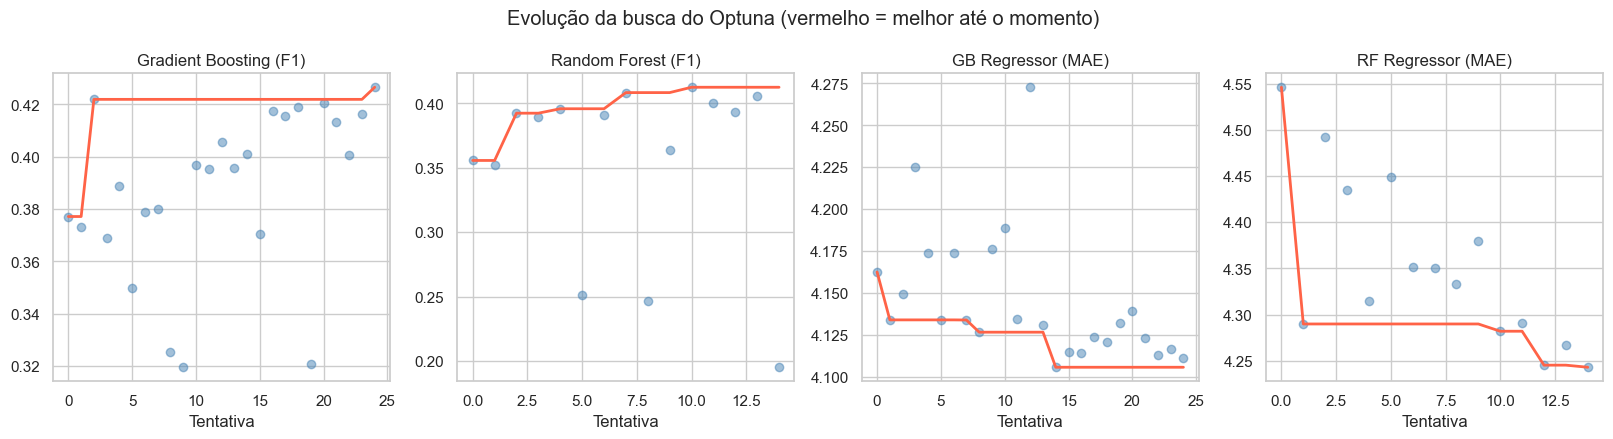

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titulos = {
    "hgb_clf": "Gradient Boosting (F1)",
    "rf_clf": "Random Forest (F1)",
    "hgb_reg": "GB Regressor (MAE)",
    "rf_reg": "RF Regressor (MAE)",
}
for ax, (k, e) in zip(axes, estudos.items()):
    v = np.array([t.value for t in e.trials]) * (-1 if k.endswith("reg") else 1)
    melhor = np.minimum.accumulate(v) if k.endswith("reg") else np.maximum.accumulate(v)
    ax.scatter(range(len(v)), v, alpha=0.5, color="steelblue")
    ax.plot(melhor, color="tomato", linewidth=2)
    ax.set_title(titulos[k])
    ax.set_xlabel("Tentativa")
plt.suptitle("Evolução da busca do Optuna (vermelho = melhor até o momento)", y=1.04)
plt.show()

Na validação, o Optuna melhorou os quatro modelos, principalmente o F1 dos classificadores. O peso
escolhido para a classe "atrasado" ficou entre 6 e 7, bem abaixo dos 11,3 do "balanced", o que indica que
a compensação anterior era exagerada.

Na classificação também foi ajustado o **limiar de decisão**. Por padrão, o modelo indica atraso quando a
probabilidade passa de 0,5, mas esse não é necessariamente o melhor ponto para o F1. O limite foi escolhido
com previsões de validação cruzada no treino, sem usar o conjunto de teste.


In [ ]:
otim_clf = {
    "Gradient Boosting (Optuna)": espaco_hgb_clf(
        optuna.trial.FixedTrial(estudos["hgb_clf"].best_params)
    ),
    "Random Forest (Optuna)": espaco_rf_clf(optuna.trial.FixedTrial(estudos["rf_clf"].best_params)),
}
otim_reg = {
    "Gradient Boosting Regressor (Optuna)": espaco_hgb_reg(
        optuna.trial.FixedTrial(estudos["hgb_reg"].best_params)
    ),
    "Random Forest Regressor (Optuna)": espaco_rf_reg(
        optuna.trial.FixedTrial(estudos["rf_reg"].best_params)
    ),
}

# O melhor de cada problema é escolhido pela validação, não pelo teste
melhor_clf = (
    "Gradient Boosting (Optuna)"
    if estudos["hgb_clf"].best_value >= estudos["rf_clf"].best_value
    else "Random Forest (Optuna)"
)
melhor_reg = (
    "Gradient Boosting Regressor (Optuna)"
    if estudos["hgb_reg"].best_value >= estudos["rf_reg"].best_value
    else "Random Forest Regressor (Optuna)"
)

proba_oof = cross_val_predict(
    criar_pipeline(otim_clf[melhor_clf]),
    X_train,
    yc_train,
    method="predict_proba",
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
)[:, 1]
limiares = np.arange(0.05, 0.96, 0.01)
f1s = [f1_score(yc_train, proba_oof >= t) for t in limiares]
limiar = limiares[int(np.argmax(f1s))]
print(f"Melhores na validação: {melhor_clf} | {melhor_reg}")
print(
    f"Limiar escolhido: {limiar:.2f} (F1 na validação: {f1_score(yc_train, proba_oof >= 0.5):.3f} -> {max(f1s):.3f})"
)

Melhores na validação: Gradient Boosting (Optuna) | Gradient Boosting Regressor (Optuna)
Limiar escolhido: 0.61 (F1 na validação: 0.435 -> 0.446)


## 8. Avaliação dos modelos

Nesta etapa o conjunto de teste é usado pela primeira vez. Todos os modelos, iniciais e otimizados, foram
treinados com o treino completo e avaliados nesses 19 mil pedidos.

### 8.1. Classificação


In [ ]:
def metricas_clf(y, proba, limiar=0.5):
    pred = (proba >= limiar).astype(int)
    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred),
        "F1": f1_score(y, pred),
        "ROC-AUC": roc_auc_score(y, proba),
        "PR-AUC": average_precision_score(y, proba),
    }


pipes_clf, probas, linhas = {}, {}, []
for nome, modelo in {**modelos_clf, **otim_clf}.items():
    pipes_clf[nome] = criar_pipeline(modelo).fit(X_train, yc_train)
    probas[nome] = pipes_clf[nome].predict_proba(X_test)[:, 1]
    linhas.append({"Modelo": nome, **metricas_clf(yc_test, probas[nome])})
linhas.append(
    {
        "Modelo": f"{melhor_clf} + limiar {limiar:.2f}",
        **metricas_clf(yc_test, probas[melhor_clf], limiar),
    }
)

teste_clf = pd.DataFrame(linhas).set_index("Modelo")
teste_clf.sort_values("F1", ascending=False).round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
Gradient Boosting (Optuna) + limiar 0.61,0.904,0.419,0.471,0.443,0.859,0.481
Gradient Boosting (Optuna),0.875,0.345,0.599,0.438,0.859,0.481
Random Forest (Optuna),0.883,0.351,0.527,0.421,0.836,0.443
Random Forest,0.922,0.530,0.344,0.418,0.848,0.460
Gradient Boosting,0.803,0.256,0.749,0.382,0.857,0.477
Árvore de Decisão,0.742,0.203,0.750,0.320,0.804,0.378
Rede Neural (MLP),0.928,0.702,0.204,0.317,0.822,0.435
Regressão Logística,0.716,0.179,0.696,0.285,0.784,0.334
KNN,0.924,0.895,0.071,0.131,0.746,0.304


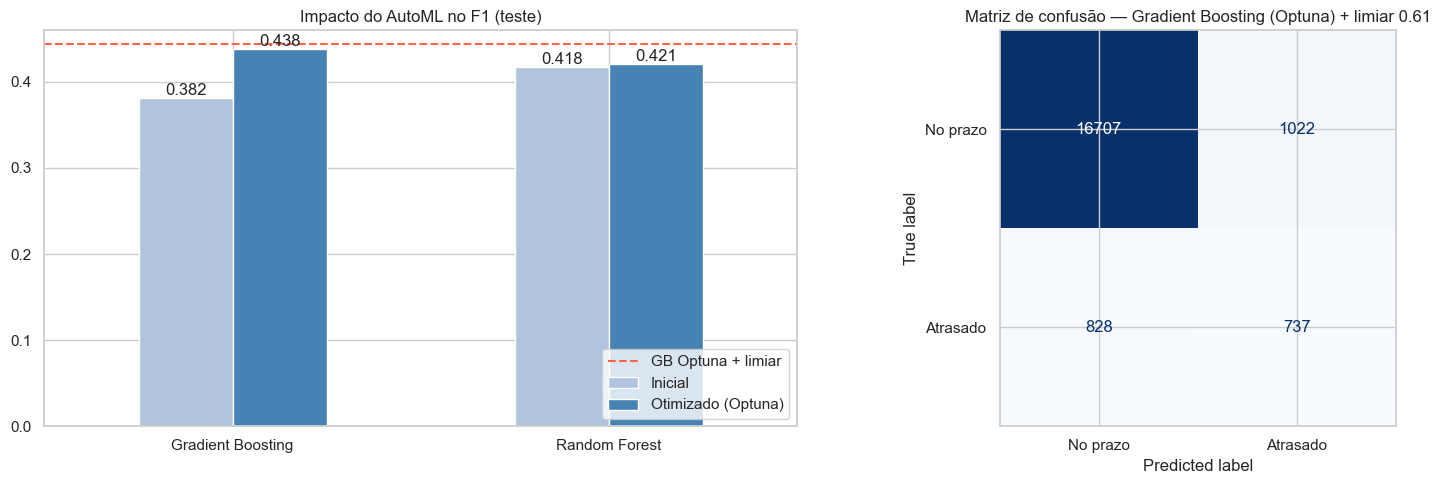

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
antes_depois = pd.DataFrame(
    {
        "Inicial": teste_clf.loc[["Gradient Boosting", "Random Forest"], "F1"].values,
        "Otimizado (Optuna)": teste_clf.loc[
            ["Gradient Boosting (Optuna)", "Random Forest (Optuna)"], "F1"
        ].values,
    },
    index=["Gradient Boosting", "Random Forest"],
)
antes_depois.plot(kind="bar", color=["lightsteelblue", "steelblue"], ax=axes[0])
axes[0].axhline(
    teste_clf.iloc[-1]["F1"], color="tomato", linestyle="--", label="GB Optuna + limiar"
)
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
    )
axes[0].set_title("Impacto do AutoML no F1 (teste)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_predictions(
    yc_test,
    (probas[melhor_clf] >= limiar).astype(int),
    display_labels=["No prazo", "Atrasado"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title(f"Matriz de confusão — {melhor_clf} + limiar {limiar:.2f}")
plt.tight_layout()
plt.show()

**Análise:**

- Os resultados no teste ficaram parecidos com os da validação cruzada, sem sinal de overfitting.
- **O melhor modelo foi o Gradient Boosting otimizado com limiar de 0,61:** F1 de 0,443, precision de
  0,42, recall de 0,47 e ROC-AUC de 0,86. Dos pedidos que o modelo alerta, 42% realmente atrasam, contra
  8% na base como um todo, e quase metade dos atrasos é identificada já no despacho.
- A accuracy desse modelo (90,4%) é menor que a do baseline (91,9%), mas ele é mais útil, confirmando
  que a accuracy não era a métrica adequada.
- **Impacto do AutoML:** no Gradient Boosting, o F1 subiu de 0,382 para 0,438 (+15%), e para 0,443 com o
  ajuste do limiar. O modelo passou a alertar menos, com mais acerto (precision de 0,26 para 0,35). No
  Random Forest, o ganho foi quase nulo (F1 de 0,418 para 0,421): a melhora vista na validação não se
  repetiu no teste.

O resultado do Random Forest mostra que o ganho do AutoML precisa ser confirmado em dados novos.


### 8.2. Regressão


In [ ]:
def metricas_reg(y, pred):
    mse = mean_squared_error(y, pred)
    return {
        "MAE": mean_absolute_error(y, pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y, pred),
    }


pipes_reg, preds, linhas = {}, {}, []
for nome, modelo in {**modelos_reg, **otim_reg}.items():
    pipes_reg[nome] = criar_pipeline(modelo).fit(X_train, yr_train)
    preds[nome] = pipes_reg[nome].predict(X_test)
    linhas.append({"Modelo": nome, **metricas_reg(yr_test, preds[nome])})

teste_reg = pd.DataFrame(linhas).set_index("Modelo")
teste_reg.sort_values("MAE").round(3)

,MAE,MSE,RMSE,R²
Modelo,,,,
Gradient Boosting Regressor (Optuna),3.925,46.822,6.843,0.531
Gradient Boosting Regressor,3.990,47.861,6.918,0.521
Random Forest Regressor (Optuna),4.011,47.872,6.919,0.521
Random Forest Regressor,4.024,47.893,6.921,0.520
Rede Neural (MLP),4.147,49.973,7.069,0.500
Árvore de Regressão,4.369,56.516,7.518,0.434
Regressão Linear,4.443,54.692,7.395,0.452
KNN Regressor,4.884,61.521,7.844,0.384
Baseline,6.737,100.505,10.025,-0.006


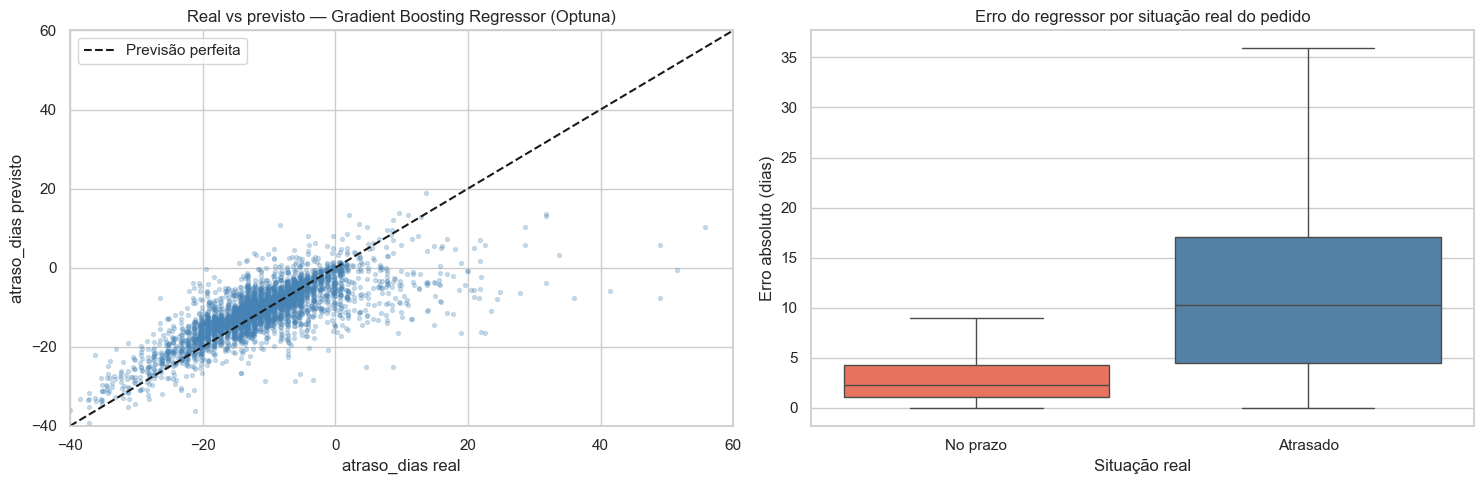

Situação real
Atrasado    12.97
No prazo     3.13


In [ ]:
pred = preds[melhor_reg]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
amostra = np.random.default_rng(RANDOM_STATE).choice(len(yr_test), 4000, replace=False)
axes[0].scatter(yr_test.values[amostra], pred[amostra], alpha=0.25, s=8, color="steelblue")
axes[0].plot([-40, 60], [-40, 60], "k--", label="Previsão perfeita")
axes[0].set_xlim(-40, 60)
axes[0].set_ylim(-40, 60)
axes[0].set_xlabel("atraso_dias real")
axes[0].set_ylabel("atraso_dias previsto")
axes[0].set_title(f"Real vs previsto — {melhor_reg}")
axes[0].legend()

erro = pd.DataFrame(
    {
        "Situação real": np.where(yr_test > 0, "Atrasado", "No prazo"),
        "Erro absoluto (dias)": np.abs(yr_test.values - pred),
    }
)
sns.boxplot(
    data=erro,
    x="Situação real",
    y="Erro absoluto (dias)",
    showfliers=False,
    ax=axes[1],
    palette=["tomato", "steelblue"],
)
axes[1].set_title("Erro do regressor por situação real do pedido")
plt.tight_layout()
plt.show()
print(erro.groupby("Situação real")["Erro absoluto (dias)"].mean().round(2).to_string())

**Análise:**

- **O melhor modelo foi o Gradient Boosting Regressor otimizado:** MAE de 3,93 dias e R² de 0,53, contra
  6,74 dias do baseline (42% menos erro).
- O AutoML ajudou pouco, mas de forma consistente. No Gradient Boosting, todas as métricas melhoraram (MAE
  de 3,99 para 3,93 e R² de 0,52 para 0,53). No Random Forest, quase não houve mudança.
- O modelo erra pouco nos pedidos entregues no prazo (cerca de 3 dias) e muito nos atrasados (cerca de 13
  dias). No gráfico real × previsto, as previsões ficam concentradas perto da média: o modelo percebe o
  risco, mas subestima os atrasos grandes, que normalmente vêm de problemas na transportadora.

Por isso, o classificador é mais adequado para gerar alertas, e o regressor serve como estimativa
aproximada de quantos dias o pedido deve atrasar.


## 9. Interpretabilidade do modelo

Foram usadas duas abordagens:

- **Feature Importance por permutação:** embaralha uma variável por vez no teste e mede quanto o modelo
  piora. Quanto maior a piora, mais importante a variável.
- **SHAP:** mostra quanto cada variável aumentou ou reduziu cada previsão. Permite ver a importância
  geral, a direção do efeito e a explicação de pedidos específicos.


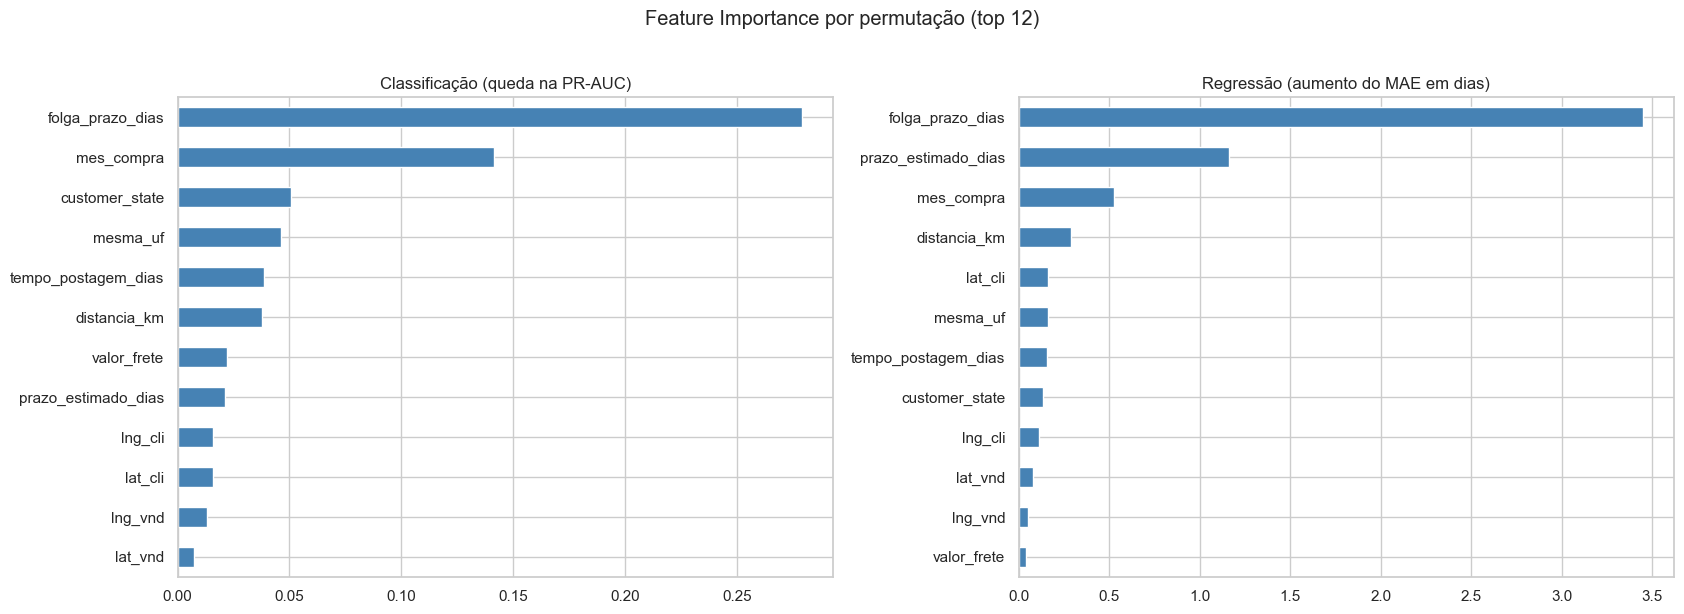

In [ ]:
idx = X_test.sample(5000, random_state=RANDOM_STATE).index
fi_clf = permutation_importance(
    pipes_clf[melhor_clf],
    X_test.loc[idx],
    yc_test.loc[idx],
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
fi_reg = permutation_importance(
    pipes_reg[melhor_reg],
    X_test.loc[idx],
    yr_test.loc[idx],
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, fi, titulo in [
    (axes[0], fi_clf, "Classificação (queda na PR-AUC)"),
    (axes[1], fi_reg, "Regressão (aumento do MAE em dias)"),
]:
    pd.Series(fi.importances_mean, index=X_test.columns).sort_values().tail(12).plot(
        kind="barh", color="steelblue", ax=ax
    )
    ax.set_title(titulo)
plt.suptitle("Feature Importance por permutação (top 12)", y=1.02)
plt.tight_layout()
plt.show()

**Análise:** nos dois modelos, a variável mais importante é `folga_prazo_dias`, criada na engenharia de
características. Em seguida vêm o mês da compra, o prazo prometido e a geografia (UF, mesma UF e
distância). Valor, frete, peso e categoria quase não influenciam, o que confirma a Pergunta 6 da EDA.


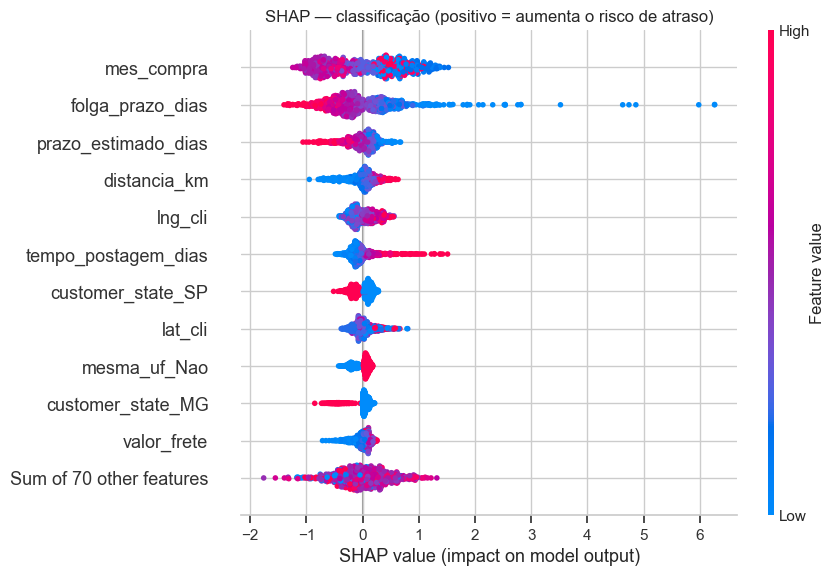

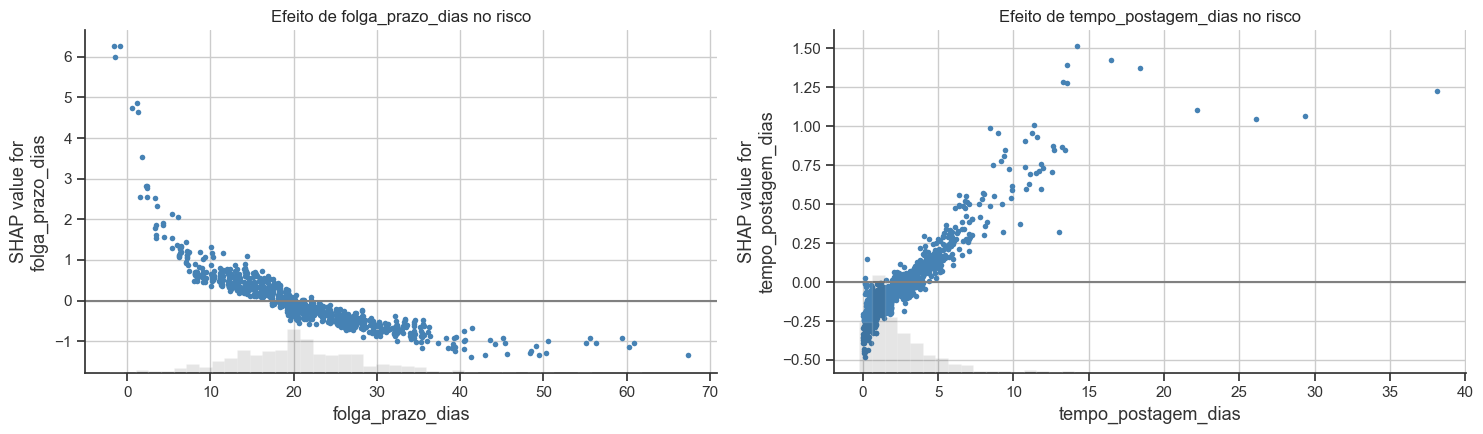

In [ ]:
def explicar_shap(pipe, X_amostra):
    """Valores SHAP do modelo de árvore, mostrando as numéricas na escala original."""
    prep, modelo = pipe.named_steps["prep"], pipe.named_steps["modelo"]
    Xt = prep.transform(X_amostra)
    exp = shap.TreeExplainer(modelo)(Xt, check_additivity=False)
    if exp.values.ndim == 3:
        exp = exp[:, :, 1]
    dados = Xt.copy()
    n = len(num_features)
    dados[:, :n] = (
        prep.named_transformers_["num"].named_steps["scaler"].inverse_transform(Xt[:, :n])
    )
    return shap.Explanation(
        exp.values, exp.base_values, dados, feature_names=list(prep.get_feature_names_out())
    )


X_shap = X_test.sample(1000, random_state=RANDOM_STATE)
shap_clf = explicar_shap(pipes_clf[melhor_clf], X_shap)

plt.figure()
shap.plots.beeswarm(shap_clf, max_display=12, show=False)
plt.title("SHAP — classificação (positivo = aumenta o risco de atraso)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, var in zip(axes, ["folga_prazo_dias", "tempo_postagem_dias"]):
    shap.plots.scatter(shap_clf[:, var], ax=ax, show=False, color="steelblue")
    ax.axhline(0, color="gray")
    ax.set_title(f"Efeito de {var} no risco")
plt.tight_layout()
plt.show()

**Análise do SHAP (classificação):**

- **Folga no despacho:** quanto menor a folga, maior o risco, mas o efeito não é linear. Abaixo de cerca
  de 20 dias o risco começa a subir e, abaixo de 5 dias, aumenta muito. Acima de 30 dias, mais folga quase
  não faz diferença.
- **Tempo de postagem:** cada dia a mais aumenta o risco de forma quase constante, como na Pergunta 3.
- **Mês da compra:** fevereiro, março e novembro aumentam o risco, os mesmos picos da Pergunta 5.
- **Outros efeitos:** prazo prometido maior reduz o risco; distância maior aumenta; clientes de SP e MG
  têm menos risco; pedidos entre UFs diferentes têm mais.

O modelo aprendeu a mesma lógica observada na análise exploratória.


Para entender pedidos específicos, foram analisados o pedido de maior risco previsto e um pedido de baixo
risco:


Pedido de alto risco: risco previsto 99.5% | atraso real +8.5 dias | RS <- SP | prazo 29 d | postagem 29.4 d | folga -0.9 d


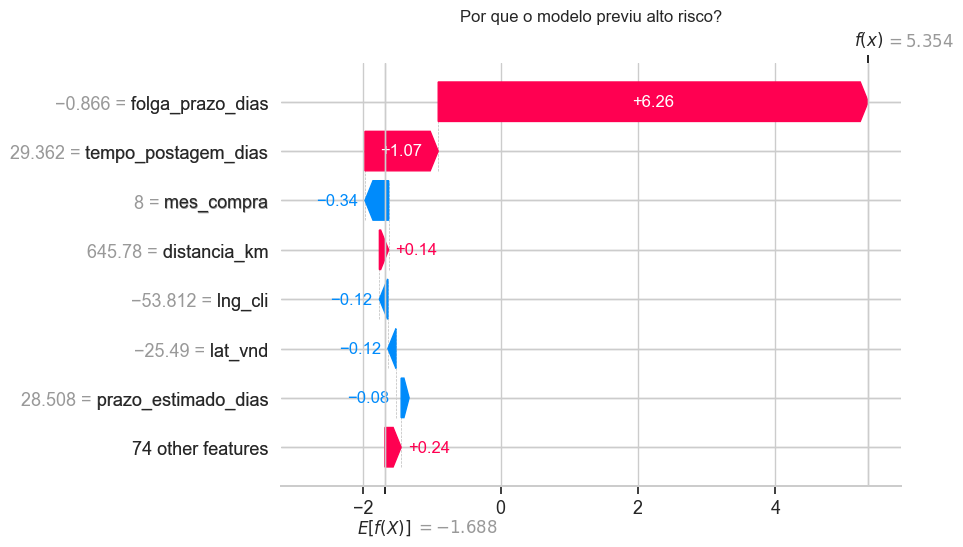

Pedido de baixo risco: risco previsto 0.8% | atraso real -40.3 dias | RJ <- SP | prazo 52 d | postagem 1.7 d | folga 50.6 d


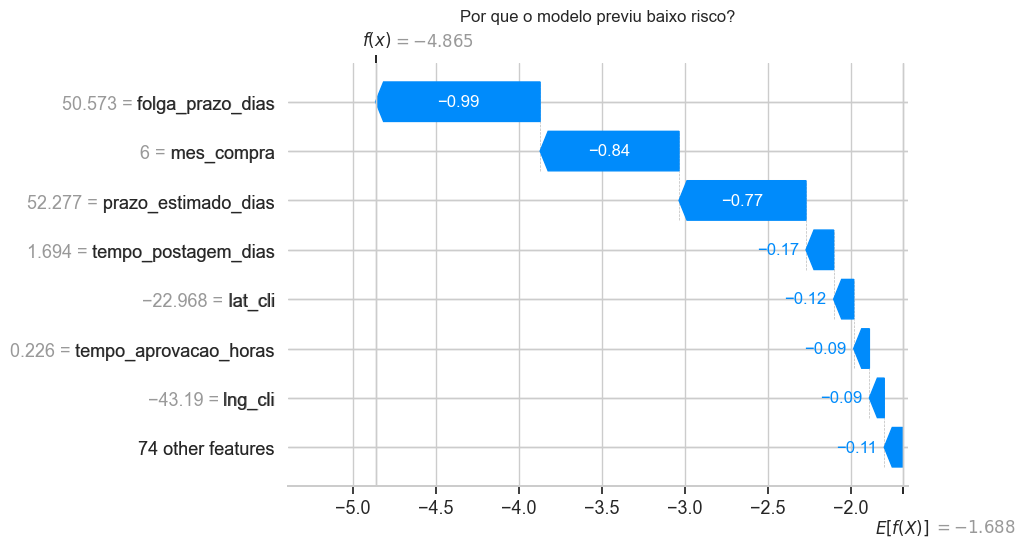

In [ ]:
proba_shap = pipes_clf[melhor_clf].predict_proba(X_shap)[:, 1]
real = yc_test.loc[X_shap.index].values
i_alto = int(np.argmax(np.where(real == 1, proba_shap, -1)))
i_baixo = int(np.argmin(np.where(real == 0, proba_shap, 2)))

for i, nome in [(i_alto, "alto risco"), (i_baixo, "baixo risco")]:
    p = X_shap.iloc[i]
    print(
        f"Pedido de {nome}: risco previsto {proba_shap[i]:.1%} | atraso real {yr_test.loc[X_shap.index[i]]:+.1f} dias | "
        f"{p['customer_state']} <- {p['seller_state']} | prazo {p['prazo_estimado_dias']:.0f} d | "
        f"postagem {p['tempo_postagem_dias']:.1f} d | folga {p['folga_prazo_dias']:.1f} d"
    )
    plt.figure()
    shap.plots.waterfall(shap_clf[i], max_display=8, show=False)
    plt.title(f"Por que o modelo previu {nome}?")
    plt.show()

**Interpretação:**

- **Pedido de alto risco (99,5%):** o vendedor levou 29 dias para postar um pedido com prazo de 29 dias.
  O pedido chegou à transportadora sem folga e atrasou 8,5 dias. O SHAP mostra que a folga negativa e a
  postagem lenta explicam quase toda a previsão, o que aponta o vendedor como responsável.
- **Pedido de baixo risco (0,8%):** prazo de 52 dias e postagem em menos de 2 dias, com 50 dias de folga.
  Chegou 40 dias antes do prometido.


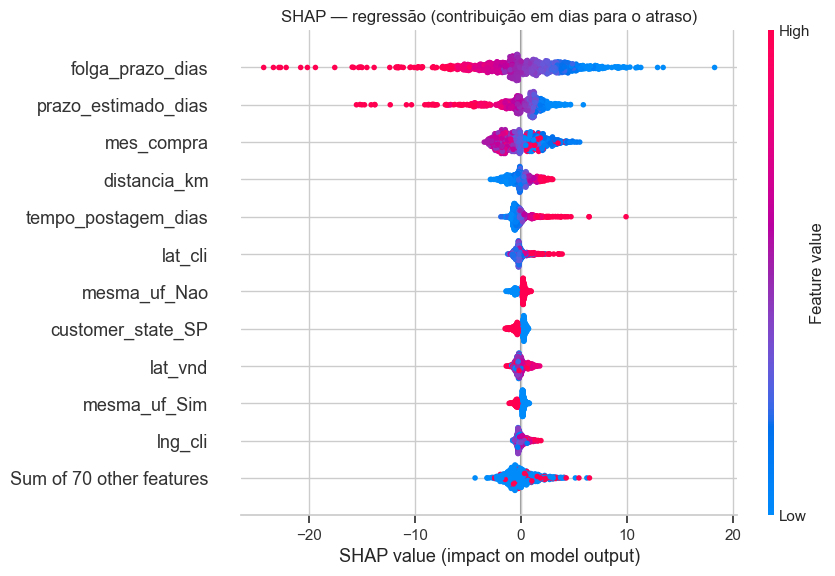

In [32]:
shap_reg = explicar_shap(pipes_reg[melhor_reg], X_shap)
plt.figure()
shap.plots.beeswarm(shap_reg, max_display=12, show=False)
plt.title("SHAP — regressão (contribuição em dias para o atraso)")
plt.show()

**Análise do SHAP (regressão):** a ordem das variáveis se mantém, agora medida em dias. Pouca folga pode
somar mais de 10 dias ao atraso previsto, e muita folga pode reduzir até 20 dias. A postagem lenta soma de
2 a 10 dias, e clientes no Rio de Janeiro somam de 1 a 3 dias, o que confirma o problema de entrega local
visto na Pergunta 4.


## 10. Conclusões

**O que foi possível descobrir durante a análise exploratória?**

O atraso é o fator que mais gera insatisfação: 54% dos clientes que recebem com atraso dão nota 1 ou 2,
contra 9% dos que recebem no prazo. O risco de atraso depende principalmente do tempo de postagem do
vendedor, da rota (UF e distância) e da época do ano (Black Friday e fevereiro/março de 2018). Valor do
pedido, frete e peso do produto praticamente não influenciam.

**Quais características dos dados parecem mais relevantes?**

A folga no despacho, que combina prazo prometido, tempo de aprovação e tempo de postagem. Depois vêm o mês
da compra, o prazo prometido, a geografia e o tempo de postagem. A EDA, a Feature Importance e o SHAP
apontaram na mesma direção.

**Como os diferentes modelos se comportaram?**

Gradient Boosting e Random Forest foram os melhores nos dois problemas. Os modelos lineares não captaram
bem os efeitos não lineares, e KNN e Rede Neural tiveram dificuldade com o desbalanceamento.

|                       | Classificação (F1)                          | Regressão (MAE)                        |
| --------------------- | ------------------------------------------- | -------------------------------------- |
| Baseline              | 0,000                                       | 6,74 dias                              |
| Melhor modelo inicial | 0,418 (Random Forest)                       | 3,99 dias (Gradient Boosting)          |
| Melhor modelo final   | 0,443 (Gradient Boosting + Optuna + limiar) | 3,93 dias (Gradient Boosting + Optuna) |

**Qual foi o impacto da otimização de hiperparâmetros?**

No Gradient Boosting, o F1 da classificação subiu 15% e a regressão teve uma melhora pequena. No Random
Forest, quase não houve mudança. A otimização ajudou, mas o maior ganho do projeto veio da engenharia de
características. O grupo também observou que a melhora na validação nem sempre se repete no teste.

**O que a análise de interpretabilidade mostrou sobre o comportamento do modelo?**

O modelo segue uma lógica coerente com o negócio: pouca folga, postagem lenta, rotas difíceis e períodos
de pico aumentam o risco. As explicações individuais mostram por que cada pedido foi considerado de risco,
o que facilita a confiança da operação no modelo.

**Quais limitações foram encontradas?**

- A divisão entre treino e teste foi aleatória, não temporal. Em uso real, o modelo seria treinado com o
  passado e aplicado no futuro, e o desempenho provavelmente seria um pouco menor.
- Não há dados da transportadora nem de rastreamento, que ajudariam a explicar os atrasos grandes.
- A precision de 42% significa que a maioria dos alertas não se confirma, então a ação tomada precisa ter
  custo baixo, como avisar o cliente.
- A busca de hiperparâmetros foi reduzida de propósito (amostra de 30 mil pedidos e 15 a 25 tentativas
  por modelo) para manter o notebook executável no Colab. Uma busca maior poderia encontrar
  configurações melhores.
- Os resultados mostram associação, não causa.

**Quais poderiam ser os próximos passos?**

1. Criar variáveis com o histórico do vendedor e da rota, como a taxa de atraso do vendedor nos últimos
   meses.
2. Fazer uma validação temporal, treinando até um mês e testando nos meses seguintes.
3. Criar um modelo para o momento da compra, para ajustar o prazo prometido por rota e época.
4. Definir o limiar de decisão com base no custo de cada tipo de erro.
5. Testar LightGBM ou CatBoost e aumentar o número de tentativas no Optuna.

**Recomendação.** Com esse modelo, a Olist pode identificar no despacho os pedidos com maior risco de
atraso e agir antes da reclamação do cliente. Em paralelo, definir um prazo máximo de postagem para os
vendedores e ajustar o prazo prometido nas rotas e épocas mais críticas atacaria as principais causas do
atraso.
